# Getting started with the two-photon data

Dandiset **001709** — OpenScope Cross-Species V2, mouse visual cortex.

This notebook opens one session and walks through what is inside it: the imaging planes,
the stimulus trials, the neurons, and the traces. It ends with three standard analyses —
a cell's activity through time, receptive fields, and an orientation tuning curve.

Everything here streams from the archive, so nothing is downloaded to disk.

## Setting up

The cell below installs everything this notebook needs, into whichever kernel is running.

If you would rather keep this in its own environment,
[DANDI's installation page](https://docs.dandiarchive.org/api/dandi-client/) covers the
command-line tool, and these three lines cover the rest:

```bash
conda create -n dandi python=3.11
conda activate dandi
pip install dandi pynwb remfile h5py numpy pandas matplotlib jupyterlab
```

Or open the notebook on [DANDI Hub](https://hub.dandiarchive.org), a JupyterHub run by the
archive where the whole stack is already installed.

In [ ]:
# Install what this notebook needs, into whichever kernel is running.
# Use %pip rather than !pip: the magic targets the kernel's own Python, while the shell
# version runs whichever pip is first on PATH, which is often a different environment.
%pip install --quiet --disable-pip-version-check dandi pynwb remfile h5py matplotlib pandas

## 1. Open one session

One NWB file holds one session. We stream it: HDF5 asks for the byte ranges it needs over
HTTP, so opening the file is fast and we only pay for the data we actually read.

In [ ]:
import os
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynwb
import remfile
from dandi.dandiapi import DandiAPIClient

# These files were written with a slightly older NWB schema than the installed pynwb, so
# opening one prints a few mismatch warnings. They are harmless -- pynwb keeps its own
# definitions and nothing we read below is affected.
warnings.filterwarnings("ignore", message="ndx-events")
warnings.filterwarnings("ignore", message="The 'manufacturer' field is deprecated")

# One session: mouse 815059, recorded on 2025-10-23.
SESSION_PATH = ("sub-815059/"
                "sub-815059_ses-multiplane-ophys-815059-2025-10-23-11-51-43_ophys.nwb")

#Start the Dandi CLI
client = DandiAPIClient()
if os.environ.get("DANDI_API_KEY"):        # only needed while the dandiset is embargoed, I'll remove it
    client.dandi_authenticate()

#Stream the nwb file
asset = client.get_dandiset("001709").get_asset_by_path(SESSION_PATH)
fileHandle = h5py.File(
    remfile.File(asset.get_content_url(follow_redirects=1, strip_query=False)), "r")
nwbfile = pynwb.NWBHDF5IO(file=fileHandle, mode="r").read()
#Show the subject number, sex, age, and genotype
print("subject       ", nwbfile.subject.subject_id, "|", nwbfile.subject.sex,
      "|", nwbfile.subject.age)
print("genotype      ", nwbfile.subject.genotype)


subject        815059 | F | P120D
genotype       Cux2-CreERT2/wt;Camk2a-tTA/wt;Ai93(TITL-GCaMP6f)/wt


## 2. Recording fields information

Eight planes were imaged at the same time (four locations, each at two depths).
Each plane is a separate processing module, and each has its own set of neurons.

In [ ]:
planeRows = [] #allocate variable to contain the plane information
for planeName, plane in nwbfile.imaging_planes.items():
    depth = int(float(plane.location.split("Depth:")[1].strip()))
    neuronTable = nwbfile.processing[planeName]["image_segmentation"]["roi_table"]

    planeRows.append({"plane": planeName,
                      "depth_um": depth,
                      "neurons": len(neuronTable)})

planeTable = pd.DataFrame(planeRows)
#display the depth and number of neurons for each plane
planeTable

812 neurons in this session



,plane,depth_um,neurons
0,VISp_0,130,153
1,VISp_1,230,42
2,VISp_2,140,138
3,VISp_3,234,32
4,VISp_4,140,91
5,VISp_5,240,135
6,VISp_6,150,99
7,VISp_7,250,122


## 3. Extract the stimulus tables

Each stimulus block is a table under `nwbfile.intervals`, with **one row per trial**.
`start_time` and `stop_time` are in seconds on the session clock — the same clock every
other signal in the file uses.

The session contains three blocks:

- **`receptive_field_block`** — a small drifting grating patch at one of 81 positions on a
  9 × 9 grid, 0.25 s per trial, presented back to back with no gap. Each row gives the
  patch position in `x_position` and `y_position` alongside its grating parameters.
- **`spontaneous`** — a single interval with no stimulus on the screen.
- **`drifting_gratings_field_block`** — a full-field drifting grating, 1 s per trial with a
  gap between trials, cycling through orientation, spatial frequency and temporal
  frequency. There are no position columns.


Beyond `start_time` and `stop_time`, every block also carries `stim_name`, `stim_type` and
`stim_index`.

In [ ]:
#List the blocks and the number of respective stimuli
for blockName, table in nwbfile.intervals.items():
    print(f"{len(table):5d} trials   {blockName}")

 1500 trials   drifting_gratings_field_block_presentations
 2430 trials   receptive_field_block_presentations
    1 trials   spontaneous_presentations


In [ ]:
#Save the tables into variables
receptiveFieldTrials = nwbfile.intervals["receptive_field_block_presentations"].to_dataframe()
gratingTrials = nwbfile.intervals["drifting_gratings_field_block_presentations"].to_dataframe()

# Stimulus parameters are stored as text, so we convert the ones we need 
for trials in (receptiveFieldTrials, gratingTrials):
    for column in ("x_position", "y_position", "orientation",
                   "spatial_frequency", "temporal_frequency", "contrast"):
        if column in trials:
            trials[column] = pd.to_numeric(trials[column], errors="coerce")
#show timing and values of the 10 first trials if the receptive field mapping trials
print("receptive field block — one row per patch presentation")
receptiveFieldTrials[["start_time", "stop_time", "x_position", "y_position",
                      "orientation"]].head(10)

receptive field block — one row per patch presentation


,start_time,stop_time,x_position,y_position,orientation
id,,,,,
0,18.65377,18.90399,-30.0,20.0,0.0
1,18.90399,19.15421,10.0,40.0,90.0


In [65]:
#show timing and values of the 10 first trials if the tuning properties trials
print("drifting gratings block — one row per grating presentation")
gratingTrials[["start_time", "stop_time", "orientation", "spatial_frequency",
               "temporal_frequency", "contrast"]].head(10)

drifting gratings block — one row per grating presentation


,start_time,stop_time,orientation,spatial_frequency,temporal_frequency,contrast
id,,,,,,
0,636.72617,637.72700,135.0,0.32,15.0,0.8
1,638.97804,639.97884,90.0,0.16,8.0,0.8
2,641.22993,642.23077,0.0,0.08,8.0,0.8
3,643.48187,644.48271,90.0,0.32,1.0,0.8
4,645.73380,646.73458,45.0,0.02,2.0,0.8
5,647.98567,648.98650,45.0,0.04,4.0,0.8
6,650.23755,651.23840,0.0,0.08,1.0,0.8
7,652.48943,653.49030,45.0,0.16,4.0,0.8
8,654.74139,655.74224,135.0,0.04,2.0,0.8


## 4. Extract information about the neurons

Each plane has a `roi_table` with one row per neuron. Alongside the classification columns
it stores an `image_mask` — a 512 × 512 array marking which pixels belong to that neuron.

We will work with one plane from here on.

In [ ]:
planeName = "VISp_2"          # this plane has the most neurons
plane = nwbfile.processing[planeName]

# Ten neurons with clear receptive fields, chosen ahead of time 
exampleNeurons = [121, 4, 93, 49, 97, 118, 5, 111, 114, 28]

neuronTable = plane["image_segmentation"]["roi_table"].to_dataframe()
print(f"{len(neuronTable)} neurons in {planeName}")
print("columns:", list(neuronTable.columns), "\n")
# Show the probability of ROIs being a soma or dendrites
neuronTable[["is_soma", "soma_probability", "is_dendrite", "dendrite_probability"]].head()

138 neurons in VISp_2
columns: ['is_soma', 'soma_probability', 'is_dendrite', 'dendrite_probability', 'image_mask'] 



,is_soma,soma_probability,is_dendrite,dendrite_probability
id,,,,
0,1,0.665497,0,1.192093e-07
1,0,0.177323,0,3.576279e-07
2,1,0.996583,0,2.294779e-06
3,1,0.999982,0,2.652407e-06
4,1,0.999957,0,2.259016e-05


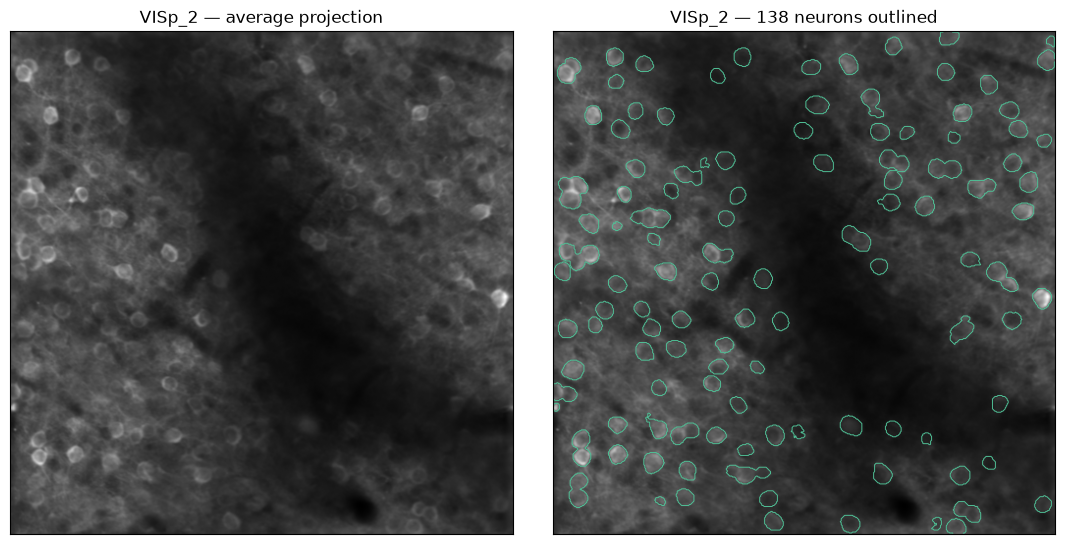

In [ ]:
#Here we'll visualize the ROIs projected onto the average image of their recording plane
# Where the neurons sit in the field of view.
averageProjection = np.asarray(plane["images"]["average_projection"].data[:])
segmentationImage = np.asarray(plane["images"]["segmentation_mask_image"].data[:])

figure, (left, right) = plt.subplots(1, 2, figsize=(11, 5.4))
left.imshow(averageProjection, cmap="gray")
left.set(title=f"{planeName} — average projection")

# segmentation_mask_image numbers every neuron, and is 0 where there is no neuron.
# Outlining it over the projection shows the segmentation against the real cells.
right.imshow(averageProjection, cmap="gray")
right.contour(segmentationImage > 0, levels=[0.5], colors="#4FBF95", linewidths=0.7)
right.set(title=f"{planeName} — {len(neuronTable)} neurons outlined")

for panel in (left, right):
    panel.set_xticks([]); panel.set_yticks([])
figure.tight_layout()
plt.show()

## 5. What is in the different variables

Every plane module holds the **same neurons** five times over, at five stages of processing.
All five have the same shape — one row per imaging frame, one column per neuron — and each
carries its own `timestamps`.

| variable | what it is |
|---|---|
| `['raw_timeseries']['ROI_fluorescence_timeseries']` | raw fluorescence summed over the neuron's pixels |
| `['neuropil_fluorescence_timeseries']` | fluorescence of the ring of surrounding tissue |
| `['neuropil_corrected_timeseries']` | raw minus a scaled version of the neuropil |
| `['dff_timeseries']['dff_timeseries']` | ΔF/F — change in fluorescence relative to baseline, in per cent |
| `['event_timeseries']` | deconvolved events: spiking activity inferred from ΔF/F |


Two variables are nested one level deeper than the rest, because they sit inside a container
that happens to share their name. That is why `['dff_timeseries']` appears twice.

Behaviour lives in its own modules, sampled at about 60 Hz, rather than the imaging rate:

| variable | what it is |
|---|---|
| `nwbfile.processing['running']['running_speed']` | treadmill speed in cm/s; negative means backwards |
| `nwbfile.processing['eye_tracking']['pupil']` | pupil ellipse per camera frame — position, area, angle |
| `nwbfile.processing['eye_tracking']['likely_blink_times']` | flags frames that are probably blinks |

In the eye tracking tables, `−1` marks a fit that failed. It is not a measurement, and it is
not `NaN`, so it has to be removed explicitly.

In [9]:
# Load the two traces we need for this plane, plus the behaviour.
dffTraces = np.asarray(plane["dff_timeseries"]["dff_timeseries"].data[:])
eventTraces = np.asarray(plane["event_timeseries"].data[:])
frameTimes = np.asarray(plane["event_timeseries"].timestamps[:])

runningSpeed = np.asarray(nwbfile.processing["running"]["running_speed"].data[:])
runningTimes = np.asarray(nwbfile.processing["running"]["running_speed"].timestamps[:])

pupilTable = nwbfile.processing["eye_tracking"]["pupil"]
pupilArea = np.asarray(pupilTable["area"].data[:], dtype=float)
pupilTimes = np.asarray(pupilTable["timestamps"].data[:], dtype=float)
pupilArea[pupilArea <= 0] = np.nan          # -1 marks a failed fit

frameRate = 1 / np.median(np.diff(frameTimes))     # differs between microscopes

print(f"dF/F and events : {dffTraces.shape[0]} frames x {dffTraces.shape[1]} neurons "
      f"at {frameRate:.2f} Hz")
print(f"running speed   : {runningSpeed.shape[0]} samples "
      f"at {1 / np.median(np.diff(runningTimes)):.1f} Hz")
print(f"pupil           : {pupilArea.shape[0]} camera frames, "
      f"{100 * np.isnan(pupilArea).mean():.1f}% failed fits")

dF/F and events : 38455 frames x 138 neurons at 9.48 Hz
running speed   : 242879 samples at 60.0 Hz
pupil           : 245247 camera frames, 0.0% failed fits


## 6. Example neurons and behavioral variables through time

Below are the dF/F and events traces alongside the animal's behavior, over 2 minute
of the drifting gratings block.

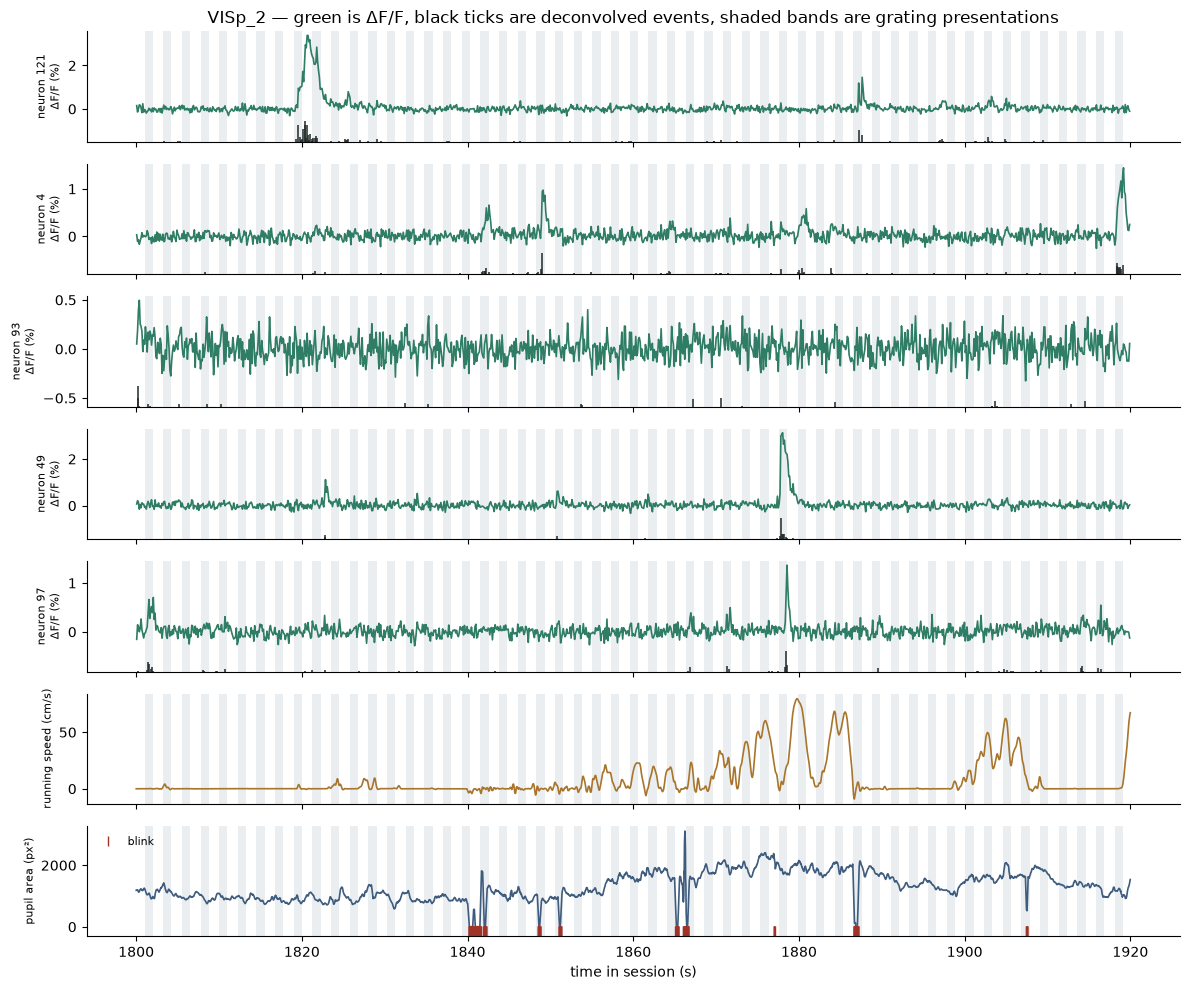

In [63]:
# The first five of the example neurons.
timecourseNeurons = exampleNeurons[:5]

# Two minute from partway through the drifting gratings block.
windowStart = 1800
windowEnd = windowStart + 120
inFrames = (frameTimes >= windowStart) & (frameTimes <= windowEnd)

figure, panels = plt.subplots(len(timecourseNeurons) + 2, 1, figsize=(12, 10), sharex=True)

# One panel per neuron: the dF/F trace, with its deconvolved events as ticks underneath.
for panel, neuron in zip(panels, timecourseNeurons):
    traceInWindow = dffTraces[inFrames, neuron]
    eventsInWindow = eventTraces[inFrames, neuron]
    panel.plot(frameTimes[inFrames], traceInWindow, color="#2E7D64", linewidth=1.2)

    # Give the event a band of their own below the trace
    span = traceInWindow.max() - traceInWindow.min()
    evBase = traceInWindow.min() - 0.32 * span
    panel.set_ylim(evBase, traceInWindow.max() + 0.05 * span)

    if eventsInWindow.max() > 0:
        fired = eventsInWindow > 0
        panel.vlines(frameTimes[inFrames][fired], evBase,
                     evBase + 0.26 * span
                     * eventsInWindow[fired] / eventsInWindow.max(),
                     color="#1F2A28", linewidth=1.1)
    panel.set_ylabel(f"neuron {neuron}\n\u0394F/F (%)", fontsize=8)

# Running and pupil are sampled near 60 Hz, a
# short rolling average makes the slow changes readable. Both share one window.
smoothingWindow = int(round(0.2 / np.median(np.diff(runningTimes))))   # ~0.5 s, in samples

# The animal's behaviour over the same minute.
behaviour = [
    ("running speed (cm/s)", runningTimes,
     pd.Series(runningSpeed).rolling(smoothingWindow, center=True, min_periods=1).mean().to_numpy(),
     "#A8752C"),
    ("pupil area (px\u00b2)", pupilTimes,
     pd.Series(pupilArea).rolling(smoothingWindow, center=True, min_periods=1).mean().to_numpy(),
     "#3E5C7E"),
]
for panel, (label, times, values, colour) in zip(panels[len(timecourseNeurons):], behaviour):
    inWindow = (times >= windowStart) & (times <= windowEnd)
    panel.plot(times[inWindow], values[inWindow], color=colour, linewidth=1.2)
    panel.set_ylabel(label, fontsize=8)

# Mark the frames flagged as blinks. Notice they correspond to sharp dips in the signal
blinkSeries = nwbfile.processing["eye_tracking"]["likely_blink_times"]
blinkFlags = np.asarray(blinkSeries.data[:], dtype=bool)
blinkTimes = np.asarray(blinkSeries.timestamps[:], dtype=float)
blinksShown = blinkTimes[blinkFlags & (blinkTimes >= windowStart)
                         & (blinkTimes <= windowEnd)]
#plot the blink times below the pupil trace
pupilFloor = panels[-1].get_ylim()[0]
panels[-1].plot(blinksShown, np.full(blinksShown.shape, pupilFloor), linestyle="none",
                marker="|", markersize=7, color="#A03328", label="blink")
panels[-1].legend(fontsize=8, frameon=False, loc="upper left")

# Mark every grating presentation in the window.
shown = gratingTrials[(gratingTrials.start_time >= windowStart) &
                      (gratingTrials.start_time <= windowEnd)]
for panel in panels:
    for trial in shown.itertuples():
        panel.axvspan(trial.start_time, trial.stop_time, color="#3E5C7E", alpha=0.10,
                      linewidth=0)
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)

panels[-1].set_xlabel("time in session (s)")
panels[0].set_title(f"{planeName} — green is \u0394F/F, black ticks are deconvolved events, "
                    f"shaded bands are grating presentations")
figure.tight_layout()
plt.show()

## 7. Receptive fields

During the receptive field block a small grating patch appears at one of 81 grid positions
for 0.25 s, then immediately moves to the next. To find a neuron's receptive field we take
either its dF/F trace or its deconvolved events (chose SIGNAL = "dF/F" or "events") in the few frames after each patch onset, then average those
responses by grid position.

Trials follow one another with no gap, so the response window has to be short — about a
third of a second.

We first prepare the data for all neurons in the plane

In [77]:
# The patch is on screen for 0.25 s, so keep the window short. Written in seconds and
# converted to frames, because the two microscopes run at different rates.
RESPONSE_FRAMES = int(round(0.3 * frameRate))
print(f"summing {RESPONSE_FRAMES} frames after each onset "
      f"({RESPONSE_FRAMES / frameRate:.2f} s)")


def responses_after_onset(traces, times, onsets, frameCount=RESPONSE_FRAMES):
    '''Sum each neuron's activity over the first few frames after every trial onset.

    Returns one row per trial, one column per neuron.
    '''
    firstFrame = np.searchsorted(times, onsets)
    window = firstFrame[:, None] + np.arange(frameCount)[None, :]
    window = np.clip(window, 0, len(times) - 1)
    return traces[window].sum(axis=1)

# How every neuron responded to every patch presentation, from each of the two traces.
patchOnsets = receptiveFieldTrials.start_time.to_numpy()
patchResponses = {"dF/F": responses_after_onset(dffTraces, frameTimes, patchOnsets),
                  "events": responses_after_onset(eventTraces, frameTimes,
                                                              patchOnsets)}

# Which grid position each trial showed.
xPositions = np.sort(receptiveFieldTrials.x_position.unique())
yPositions = np.sort(receptiveFieldTrials.y_position.unique())
columnIndex = np.searchsorted(xPositions, receptiveFieldTrials.x_position.to_numpy())
rowIndex = np.searchsorted(yPositions, receptiveFieldTrials.y_position.to_numpy())

# Average the responses at each position, giving rows x columns x neurons per trace.
receptiveFields = {}
for signal, responses in patchResponses.items():
    maps = np.zeros((len(yPositions), len(xPositions), responses.shape[1]))
    for row in range(len(yPositions)):
        for column in range(len(xPositions)):
            atThisPosition = (rowIndex == row) & (columnIndex == column)
            maps[row, column] = responses[atThisPosition].mean(axis=0)
    receptiveFields[signal] = maps

print(f"{len(xPositions)} x {len(yPositions)} grid, "
      f"{int(np.sum((rowIndex == 0) & (columnIndex == 0)))} repeats of each position")

summing 3 frames after each onset (0.32 s)
9 x 9 grid, 30 repeats of each position


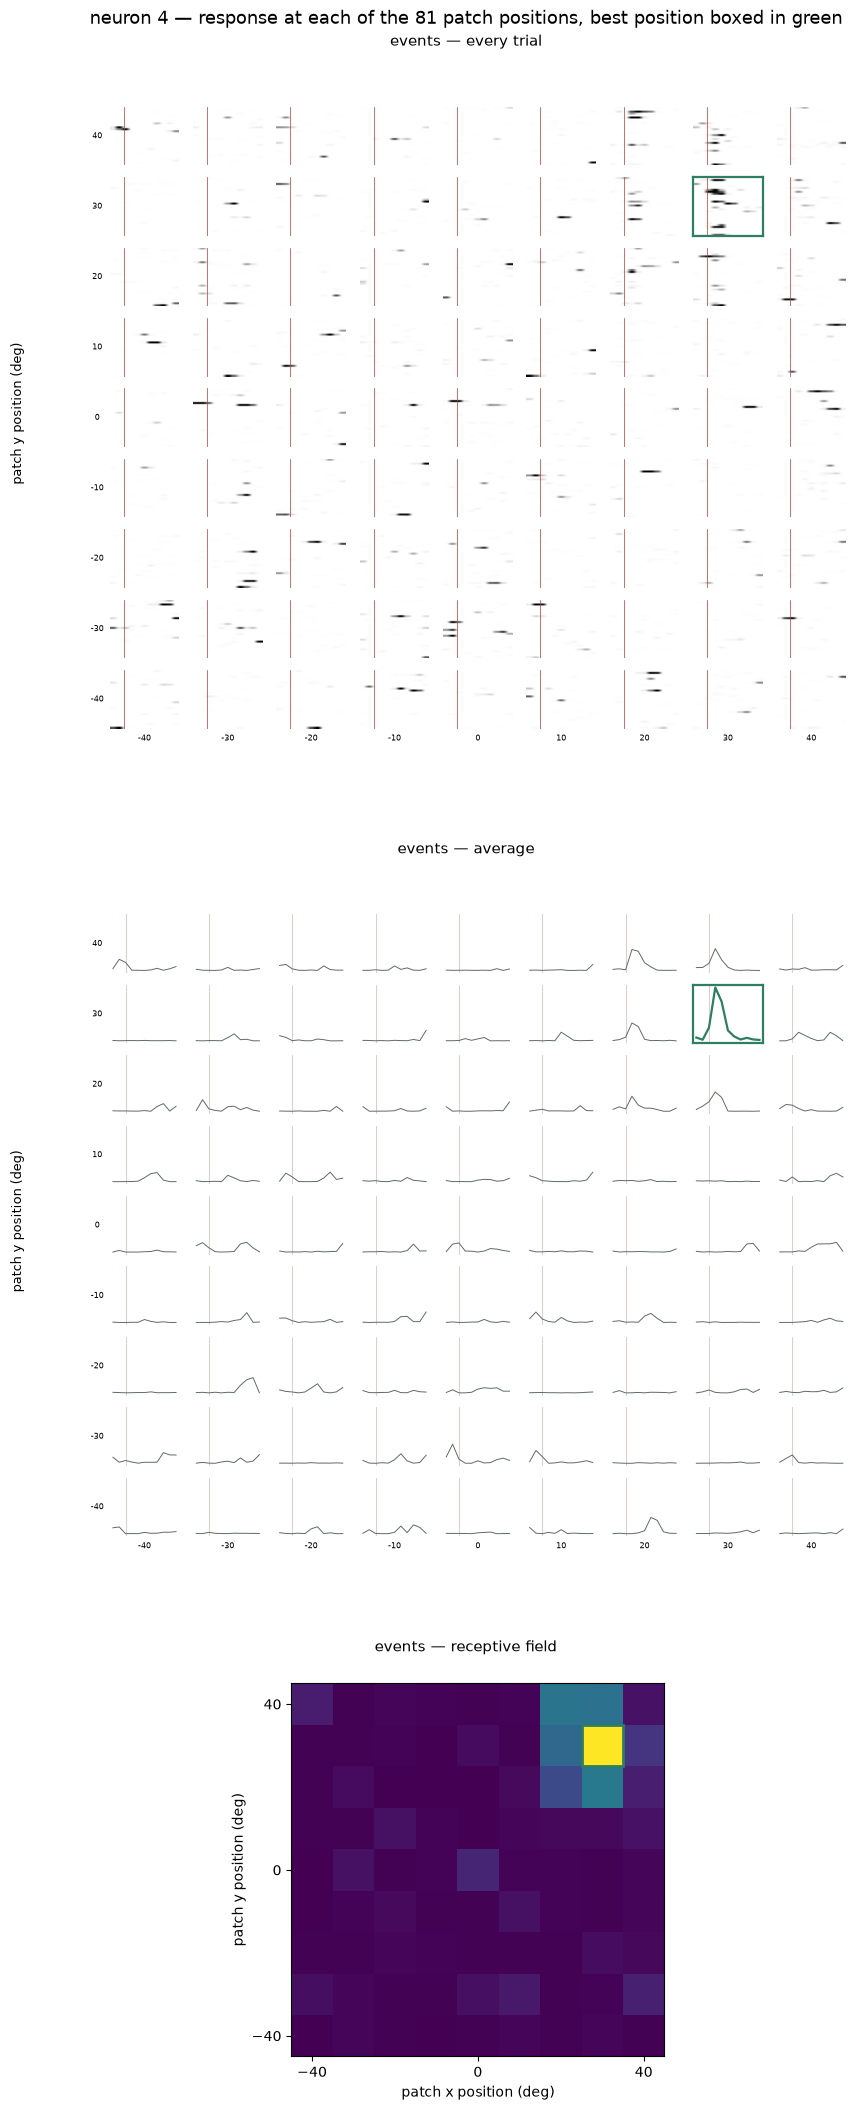

In [78]:
# One neuron in detail, before summarising ten of them.
# Which trace to use, here and for the ten receptive fields below. Set to dF/F or events
SIGNAL = "events"

detailNeuron = exampleNeurons[1]

# A window of frames around every patch onset, giving trials x frames.
patchWindow = np.arange(-2, 9)                      # about -0.2 to +0.9 s
patchOnsetFrame = np.searchsorted(frameTimes, receptiveFieldTrials.start_time.to_numpy())
patchFrames = np.clip(patchOnsetFrame[:, None] + patchWindow[None, :],
                      0, len(frameTimes) - 1)
patchLag = patchWindow / frameRate
aligned = (dffTraces if SIGNAL == "dF/F" else eventTraces)[patchFrames, detailNeuron]

# The grid position this neuron responded to most strongly.
bestRow, bestColumn = np.unravel_index(
    receptiveFields[SIGNAL][:, :, detailNeuron].argmax(),
    receptiveFields[SIGNAL][:, :, detailNeuron].shape)

# The two traces need different grey scales. dF/F is noise around zero, so take percentiles
# over everything. Events are 94% exact zeros, which would drag any percentile to nothing,
# so scale those on the values that are actually nonzero.
if SIGNAL == "dF/F":
    lower, upper = np.percentile(aligned, [2, 99.5])
else:
    lower, upper = 0.0, np.percentile(aligned[aligned > 0], 97)

# Every trial on top, the average of them in the middle, and the receptive field they
# collapse into at the bottom.
figure = plt.figure(figsize=(9.5, 21))
blocks = figure.subfigures(3, 1, hspace=0.0, height_ratios=[1, 1, 0.6])

for blockRow, kind in enumerate(["every trial", "average"]):
    block = blocks[blockRow]
    panels = block.subplots(len(yPositions), len(xPositions), sharex=True, sharey=True)

    for row in range(len(yPositions)):
        for column in range(len(xPositions)):
            # subplot row 0 is the top, so flip to put high y at the top.
            panel = panels[len(yPositions) - 1 - row][column]
            atThisPosition = (rowIndex == row) & (columnIndex == column)
            isBest = (row, column) == (bestRow, bestColumn)

            if kind == "average":
                panel.axvline(0, color="#DCC3BF", linewidth=0.6)
                panel.plot(patchLag, aligned[atThisPosition].mean(axis=0),
                           color="#2E7D64" if isBest else "#5C6B68",
                           linewidth=1.6 if isBest else 0.7)
            else:
                panel.imshow(aligned[atThisPosition], aspect="auto", cmap="Greys",
                             origin="lower", vmin=lower, vmax=upper,
                             extent=[patchLag[0], patchLag[-1], 0, atThisPosition.sum()])
                panel.axvline(0, color="#B03A2E", linewidth=0.5)

            panel.set_xticks([]); panel.set_yticks([])
            for side in ("top", "right", "bottom", "left"):
                panel.spines[side].set_visible(isBest)
                if isBest:
                    panel.spines[side].set_color("#2E7D64")
                    panel.spines[side].set_linewidth(1.6)

    for column, x in enumerate(xPositions):
        panels[-1][column].set_xlabel(f"{x:.0f}", fontsize=6)
    for row, y in enumerate(yPositions):
        panels[len(yPositions) - 1 - row][0].set_ylabel(f"{y:.0f}", fontsize=6,
                                                        rotation=0, labelpad=9,
                                                        va="center")
    block.supylabel("patch y position (deg)", fontsize=9)
    block.suptitle(f"{SIGNAL} — {kind}", fontsize=11, y=0.97)

# The receptive field itself: each position collapsed to its response in the short
# window, drawn the same way as the ten-neuron summary that follows.
gridEdges = [xPositions.min() - 5, xPositions.max() + 5,
             yPositions.min() - 5, yPositions.max() + 5]
fieldPanel = blocks[2].subplots()
fieldPanel.imshow(receptiveFields[SIGNAL][:, :, detailNeuron], origin="lower",
                  cmap="viridis", extent=gridEdges)
fieldPanel.add_patch(plt.Rectangle((xPositions[bestColumn] - 5, yPositions[bestRow] - 5),
                                   10, 10, fill=False, edgecolor="#2E7D64", linewidth=2))
fieldPanel.set(xlabel="patch x position (deg)", ylabel="patch y position (deg)",
               xticks=[-40, 0, 40], yticks=[-40, 0, 40])
blocks[2].suptitle(f"{SIGNAL} — receptive field", fontsize=11, y=0.97)

figure.suptitle(f"neuron {detailNeuron} — response at each of the 81 patch positions, "
                f"best position boxed in green", fontsize=13, y=1.0)
plt.show()

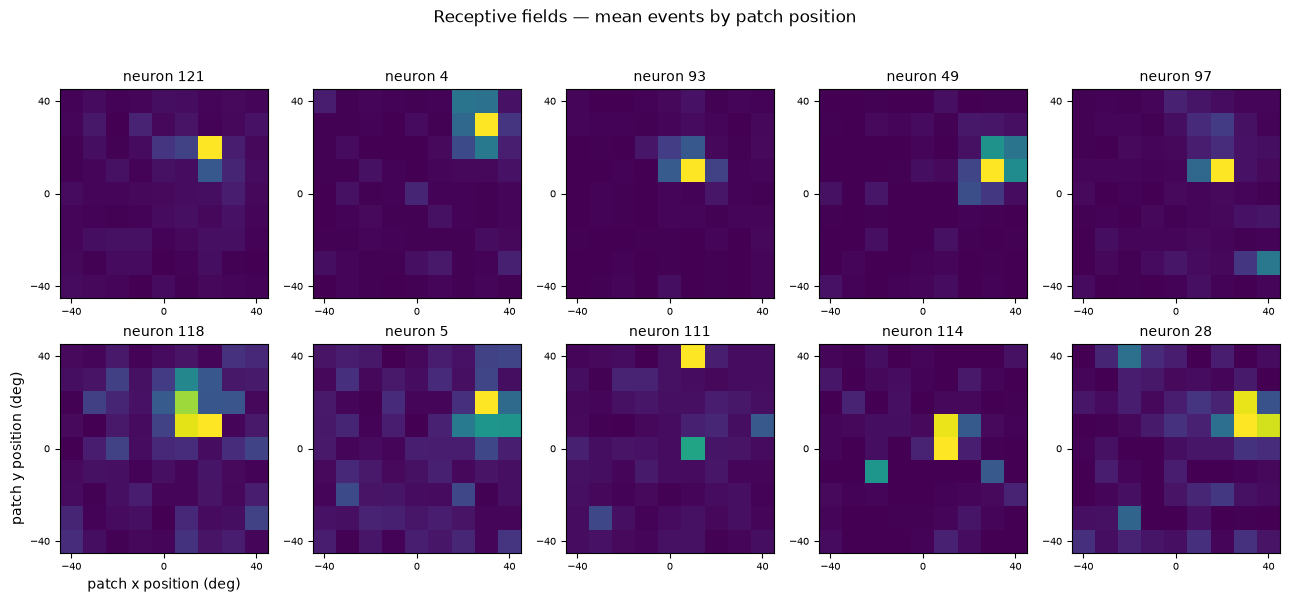

In [79]:
figure, panels = plt.subplots(2, 5, figsize=(13, 6.0))
for panel, neuron in zip(panels.flat, exampleNeurons):
    panel.imshow(receptiveFields[SIGNAL][:, :, neuron], origin="lower", cmap="viridis",
                 extent=gridEdges)
    panel.set_title(f"neuron {neuron}", fontsize=10)
    panel.set_xticks([-40, 0, 40])
    panel.set_yticks([-40, 0, 40])
    panel.tick_params(labelsize=7)

panels[1][0].set_xlabel("patch x position (deg)")
panels[1][0].set_ylabel("patch y position (deg)")
figure.suptitle(f"Receptive fields — mean {SIGNAL} by patch position", fontsize=12)
figure.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0)
plt.show()

## 8. Orientation tuning

The drifting gratings block shows a full-field grating for 1 s at a time, cycling through
four orientations and a range of spatial and temporal frequencies. Averaging a neuron's
response by orientation — pooling over the other parameters — gives a tuning curve.

Gratings last a full second with a gap between them, so the response window can be longer
than it was for the patches.

These are the same ten neurons as above, so you can read each one's receptive field and its
orientation preference together.

In [13]:
GRATING_FRAMES = int(round(1.0 * frameRate))   # gratings last 1 s, so use a longer window

gratingResponses = responses_after_onset(eventTraces, frameTimes,
                                         gratingTrials.start_time.to_numpy(),
                                         frameCount=GRATING_FRAMES)
orientations = np.sort(gratingTrials.orientation.unique())
print("orientations shown:", orientations, "degrees")


def orientation_tuning(neuron):
    '''Mean response and standard error at each orientation, for one neuron.'''
    means, errors = [], []
    for orientation in orientations:
        atThisOrientation = gratingTrials.orientation.to_numpy() == orientation
        responses = gratingResponses[atThisOrientation, neuron]
        means.append(responses.mean())
        errors.append(responses.std() / np.sqrt(len(responses)))
    return np.array(means), np.array(errors)

orientations shown: [  0.  45.  90. 135.] degrees


In [ ]:
# The same neuron, now against grating orientation.
gratingWindow = np.arange(-3, 16)                   # about -0.3 to +1.6 s
gratingOnsetFrame = np.searchsorted(frameTimes, gratingTrials.start_time.to_numpy())
gratingFrames = np.clip(gratingOnsetFrame[:, None] + gratingWindow[None, :],
                        0, len(frameTimes) - 1)
alignedGrating = eventTraces[gratingFrames, detailNeuron]
gratingLag = gratingWindow / frameRate

# Sort the trials by orientation so each block of rows is one orientation.
trialOrientation = gratingTrials.orientation.to_numpy()
byOrientation = np.argsort(trialOrientation, kind="stable")

figure, (raster, psth) = plt.subplots(1, 2, figsize=(11, 4.0))

raster.imshow(alignedGrating[byOrientation], aspect="auto", cmap="Greys", origin="lower",
              extent=[gratingLag[0], gratingLag[-1], 0, len(byOrientation)])
boundary = 0
for orientation in orientations[:-1]:
    boundary += int(np.sum(trialOrientation == orientation))
    raster.axhline(boundary, color="#3E5C7E", linewidth=0.8)
raster.axvline(0, color="#B03A2E", linewidth=1)
raster.set(xlabel="time from grating onset (s)", ylabel="trial, grouped by orientation",
           title=f"neuron {detailNeuron}, all {len(gratingTrials)} gratings")

for orientation in orientations:
    atThisOrientation = trialOrientation == orientation
    psth.plot(gratingLag, alignedGrating[atThisOrientation].mean(axis=0),
              linewidth=1.8, label=f"{orientation:.0f}\u00b0")
psth.axvline(0, color="#B03A2E", linewidth=1)
psth.set(xlabel="time from grating onset (s)", ylabel="mean deconvolved event",
         title="averaging each of these gives one point of the tuning curve")
psth.legend(fontsize=8, frameon=False, title="orientation", title_fontsize=8)

for panel in (raster, psth):
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)
figure.tight_layout()
plt.show()

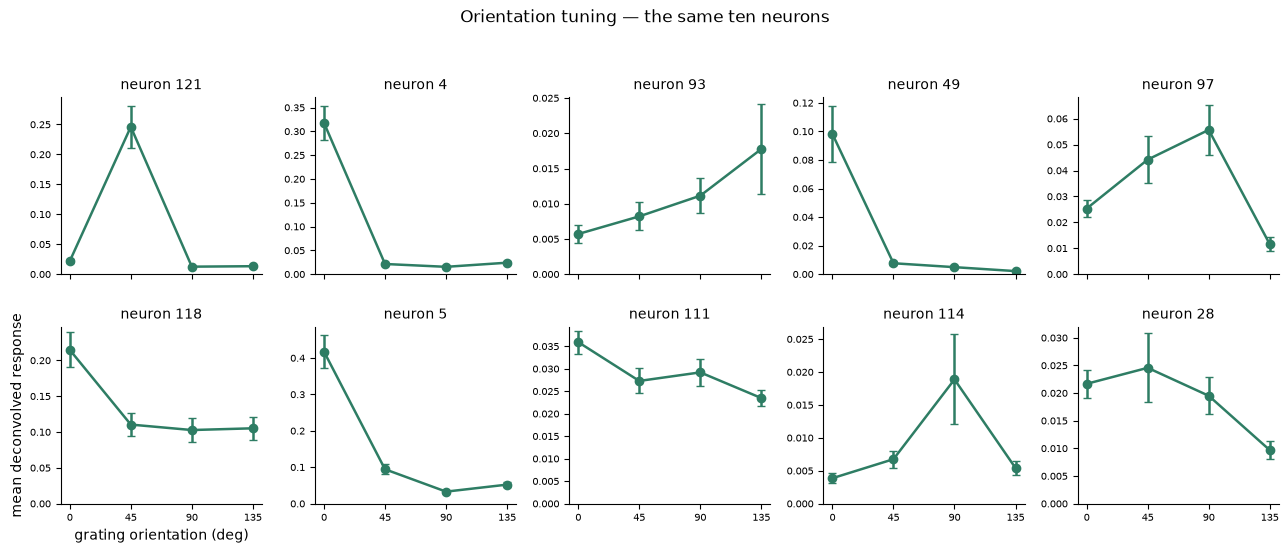

In [14]:
figure, panels = plt.subplots(2, 5, figsize=(13, 5.6), sharex=True)
for panel, neuron in zip(panels.flat, exampleNeurons):
    means, errors = orientation_tuning(neuron)
    panel.errorbar(orientations, means, yerr=errors, marker="o", markersize=6,
                   linewidth=1.8, capsize=3, color="#2E7D64")
    panel.set_title(f"neuron {neuron}", fontsize=10)
    panel.set_xticks(orientations)
    panel.tick_params(labelsize=7)
    panel.set_ylim(bottom=0)
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)

panels[1][0].set_xlabel("grating orientation (deg)")
panels[1][0].set_ylabel("mean deconvolved response")
figure.suptitle("Orientation tuning — the same ten neurons", fontsize=12)
figure.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0)
plt.show()

## 9. Closing the file

Streaming keeps a connection open, so close both handles when you are done.

In [15]:
fileHandle.close()